# Structural changes in the Russian SME sector — descriptive pipeline

Reproducible Python port of the original Excel study *MSP_Fragmentation_Analysis.xlsx* (May 2024 – Apr 2026). Everything is descriptive; see `EXECUTIVE_SUMMARY.md`. Tax receipts (form 1-NOM) and credit (CBR key-rate) data are deliberately not linked.

Same four analytical blocks (national trend, OKVED classes, regions, region×OKVED matrix) with bootstrap 95% confidence intervals and a sensitivity check that replaces the causal (DiD) design of the original study.

In [1]:
import sys
sys.path.insert(0, "..")

import src.analysis as A
print('root:', A.ROOT)
print('raw csv:', A.RAW_CSV)
print(A.__doc__.splitlines()[0])

root: /Users/kaiserreich/Desktop/MSU-BIT/Проекты/MSP_publish
raw csv: /Users/kaiserreich/Desktop/MSU-BIT/Проекты/MSP_publish/data/raw/msp_final.csv
Descriptive analysis of the Russian SME register (May 2024 - April 2026).


## Run the whole pipeline

One call reproduces the full analysis: cleaning, four blocks, bootstrap CIs, sensitivity table, all figures and processed CSVs.

In [2]:
res = A.run_pipeline(seed=42, n_iter=5000, save_outputs=True, make_plots=True)

print('result keys:', sorted(res.keys()))

result keys: ['anomaly_diagnostics', 'block1', 'block1_table', 'block2_all', 'block2_top15', 'block3_all', 'block3_top15', 'block4_long', 'block4_pivot', 'block4_summary', 'cleaning', 'cleaning_scenarios', 'lagged_compensation_similarity', 'n_iter', 'period_shape', 'robustness', 'seed', 'spike_margins', 'threshold_sensitivity']


### Anomaly diagnostics & cleaning scenarios

`detect_anomalous_months` flags abnormal months by flow magnitude alone; `anomaly_diagnostics` reconciles flows with stocks (`new_small - closed_small` vs the observed change of `active_small`) and checks neighbouring registration waves, to label the month as *churn* / *lagged_compensation* (closures matched by same- or next-month registrations — a pattern consistent with registry re-categorisation or a delayed adjustment) or *provisional_net_exit* (an unresolved exit pattern; the compensating flow is restricted to `new_small`, since the losses are small-enterprise losses). Both July spikes are *churn*: new_small itself spikes ~8–11× its median and the small-enterprise stock grows. The pattern is consistent with the documented annual FNS register review — a secondary/reference source puts the annual SME-register review on 10 July (exclusion of non-qualifying enterprises, prior-year reporting check, removal of previous-year registration marks), matching both spikes landing on the same date two years running.

Two alternative cleaning specifications result (data/processed/cleaning_scenarios.csv):

- **`exclude_compensation_patterns`** — drop the Julys and 2026-02 (lagged-compensation), keep 2026-04: closures **+276.3%**;
- **`exclude_all_flagged` (headline)** — drop all four flagged months: closures **+59.1%**.

In [3]:
diag = res['anomaly_diagnostics']
print('anomaly_diagnostics (flagged months, flow/stock reconciliation):\n')
print(diag[['month', 'anomaly_type', 'closed_small', 'new_small',
           'actual_delta_small', 'implied_delta_small', 'new_small_x_median']]
      .to_string(index=False))

print('\ncleaning_scenarios (Block 1 under each cleaning):\n')
print(res['cleaning_scenarios'][['scenario', 'label', 'months_dropped',
          'n_before', 'n_after', 'closed_pct', 'closed_pct_ci',
          'K_ratio', 'K_ratio_ci']].to_string(index=False))

anomaly_diagnostics (flagged months, flow/stock reconciliation):

  month         anomaly_type  closed_small  new_small  actual_delta_small  implied_delta_small  new_small_x_median
2024-07                churn        7625.0     1364.0             15458.0              -6261.0           11.134694
2025-07                churn        8343.0     1024.0             11931.0              -7319.0            8.359184
2026-02  lagged_compensation        5299.0       49.0             -5253.0              -5250.0            0.400000
2026-04 provisional_net_exit       12346.0       51.0            -12299.0             -12295.0            0.416327

cleaning_scenarios (Block 1 under each cleaning):

                     scenario                                                                             label                     months_dropped  n_before  n_after  closed_pct closed_pct_ci  K_ratio     K_ratio_ci
exclude_compensation_patterns A: exclude compensation patterns (same-month + lagged), retai

### Block 1 — national before/after

Mean monthly small-enterprise closures, new micro-enterprise registrations and the fragmentation coefficient `K = (new + 1) / (closed + 1)` (Laplace-smoothed, matching the smoothed figure used in the Excel report, §4.4), with 95% percentile bootstrap CIs from resampling calendar months within each period (7 before, 13 after).

In [4]:
print(res['block1_table'][['metric', 'label', 'before', 'after', 'before_ci',
                        'after_ci', 'diff', 'pct_change', 'pct_ci', 'diff_ci',
                        'zero_in_diff_ci']].to_string(index=False))
nat = res['block1']['national']
print(f"\nratio K_after/K_before = {nat['ratio_K']['value']:.3f} "
      f"(95% CI {nat['ratio_K']['ci'][0]:.3f} .. {nat['ratio_K']['ci'][1]:.3f})")

      metric                                          label        before         after            before_ci             after_ci         diff  pct_change        pct_ci             diff_ci  zero_in_diff_ci
closed_small          Small-enterprise closures (avg/month)    383.857143    610.846154       [348.1, 428.7]       [542.2, 688.0]   226.989011   59.133721  [35.2, 86.2]      [145.0, 313.0]            False
   new_micro New micro-enterprise registrations (avg/month) 113683.571429 125946.538462 [102924.3, 127021.4] [107112.8, 151374.8] 12262.967033   10.786930  [-9.5, 36.7] [-11461.7, 39946.1]             True
           K            Fragmentation coefficient (Laplace)    295.394209    205.848378       [243.1, 353.8]       [168.2, 264.7]   -89.545831  -30.314010 [-47.6, -5.2]     [-161.0, -13.7]            False
     K_ratio                       Ratio K_after / K_before    295.394209    205.848378                    —                    —   -89.545831  -30.314010    [0.5, 0.9]        

### Block 2 — OKVED classes

Top-15 classes ranked by `K_after` (Fragmentation coefficient in the after period), same ranking as the Excel sheet `Блок_2`. Labels from the OKVED-2 classifier. *Note:* `K` can be unstable for classes with very low closure counts, so the ranking should be interpreted jointly with the underlying closure and registration volumes.

In [5]:
print(res['block2_top15'][['okved', 'okved_name', 'K_before', 'K_after',
                        'K_after_ci', 'K_ratio', 'ratio_includes_one']]
      .to_string(index=False))

okved                                               okved_name    K_before     K_after      K_after_ci  K_ratio  ratio_includes_one
   85                                                Education 1332.111111 1043.000000 [810.4, 1451.8] 0.782968                True
   49                    Land transport and pipeline transport  749.540230  808.075269 [594.9, 1094.7] 1.078095                True
   96                        Other personal service activities 1137.652174  756.987013 [547.5, 1025.8] 0.665394                True
   74  Other professional, scientific and technical activities  872.000000  689.968750  [550.0, 918.2] 0.791249                True
   95        Repair of computers, personal and household goods  604.400000  574.086957  [390.5, 886.1] 0.949846                True
   63                           Information service activities  346.230769  498.254902  [356.3, 758.6] 1.439083                True
   73                          Advertising and market research  506.621622  

### Block 3 — regions

Top-15 regions by small-enterprise closures (avg/month) in the after period, with bootstrap CIs and the closure `% change`. All 15 selected regions have 95% bootstrap CIs for the before/after difference that exclude zero; these intervals are descriptive because the regions were selected using observed after-period data.

In [6]:
print(res['block3_top15'][['region_code', 'region', 'closed_small_avg_before',
                        'closed_small_avg_after', 'closed_after_ci',
                        'closed_pct_change', 'zero_in_diff_ci']]
      .to_string(index=False))

region_code                    region  closed_small_avg_before  closed_small_avg_after closed_after_ci  closed_pct_change  zero_in_diff_ci
         77                    Moscow                80.714286              122.307692  [100.7, 148.6]          51.531654            False
         78          Saint Petersburg                38.000000               56.538462    [50.2, 63.8]          48.785425            False
         50             Moscow Oblast                23.000000               36.153846    [30.5, 42.5]          57.190635            False
         66         Sverdlovsk Oblast                13.285714               21.538462    [17.6, 26.8]          62.117452            False
         23            Krasnodar Krai                14.285714               21.307692    [18.5, 24.5]          49.153846            False
         54        Novosibirsk Oblast                 9.428571               15.538462    [12.0, 19.2]          64.801865            False
         16     Republic of

### Block 4 — region × OKVED matrix

Change of the fragmentation coefficient per active pair during 2024 with 2025–2026 (ordered so the heatmap matches the Excel `Матрица`: **OKVED classes on the X axis, regions on the Y axis**). Cells with fewer than 3 active months in **either** period are flagged *insufficient (NaN)* and excluded instead of being silently set to 1 as in the Excel version.

In [7]:
piv = res['block4_pivot']
print('pivot shape (regions x okved):', piv.shape)
mat = res['block4_summary']
print(f"total pairs {mat['n_pairs_total']} | sufficient {mat['n_pairs_sufficient']} "
      f"| insufficient {mat['n_pairs_insufficient']} "
      f"(change_ratio -> NaN, threshold >= {mat['min_active_months']} active months)\n")
for cat, n in mat['categories'].items():
    print(f'  {cat}: {n}')

pivot shape (regions x okved): (85, 88)
total pairs 7152 | sufficient 4734 | insufficient 2418 (change_ratio -> NaN, threshold >= 3 active months)

  fragmentation up (>1): 2887
  fragmentation down (<1): 1821
  no change (==1): 26


### Sensitivity (alternative cleaning definitions)

The original study used a causal (DiD) design; that inference is **out of scope** here. Instead we stress the headline Block 1 statistic (closure `% change`) across cleaning choices. The anomaly classification describes the flag: the two Julys show a churn pattern (closures matched by same-month registrations, consistent with the documented annual FNS reclassification), 2026-02 is a lagged compensation pattern and 2026-04 an unresolved exit pattern. The headline (`exclude_all_flagged`, all four dropped) reads +59.1%; `exclude_compensation_patterns`, which retains the unresolved 2026-04, reads +276.3% — the whole gap is that single month's treatment, which aggregate data cannot resolve.

In [8]:
print(res['robustness'][['variant', 'label', 'n_before', 'n_after', 'closed_pct',
                        'd_closed_pp', 'new_pct', 'd_new_pp', 'K_pct', 'd_K_pp']]
      .to_string(index=False))

   variant                                    label  n_before  n_after  closed_pct  d_closed_pp   new_pct   d_new_pp      K_pct     d_K_pp
      base                     Auto rule (7m / 13m)         7       13   59.133721     0.000000 10.786930   0.000000 -30.314010   0.000000
    manual Manual Excel rule (July only) (7m / 15m)         7       15  341.865773   282.732053  8.140633  -2.646297 -75.477079 -45.163068
 july_kept  July kept (2026 spikes only) (8m / 14m)         8       14   -9.824892   -68.958613  8.338577  -2.448353  20.132216  50.446226
+region_00              Excluded region 00 re-added         7       13   59.133721     0.000000 10.786930   0.000000 -30.314010   0.000000
+region_90              Excluded region 90 re-added         7       13   59.095460    -0.038261 10.626370  -0.160560 -30.398346  -0.084335
+region_93              Excluded region 93 re-added         7       13   59.400599     0.266879 10.919775   0.132845 -30.347272  -0.033261
+region_94              Exc

### Figures

All figures are written to `../figures/`:

- `fig1_national_trend.png` — monthly time series, July spikes marked;
- `fig2_block1.png` — Block 1 bars with bootstrap CIs;
- `fig3_block2_okved.png` — top-15 OKVED;  
- `fig4_block3_regions.png` — top-15 regions;  
- `fig5_matrix_heatmap.png` — region×OKVED heatmap;  
- `fig6_robustness.png` — sensitivity of the headline effect.

figures in /Users/kaiserreich/Desktop/MSU-BIT/Проекты/MSP_publish/figures : ['fig1_national_trend.png', 'fig2_block1.png', 'fig3_block2_okved.png', 'fig4_block3_regions.png', 'fig5_matrix_heatmap.png', 'fig6_robustness.png']


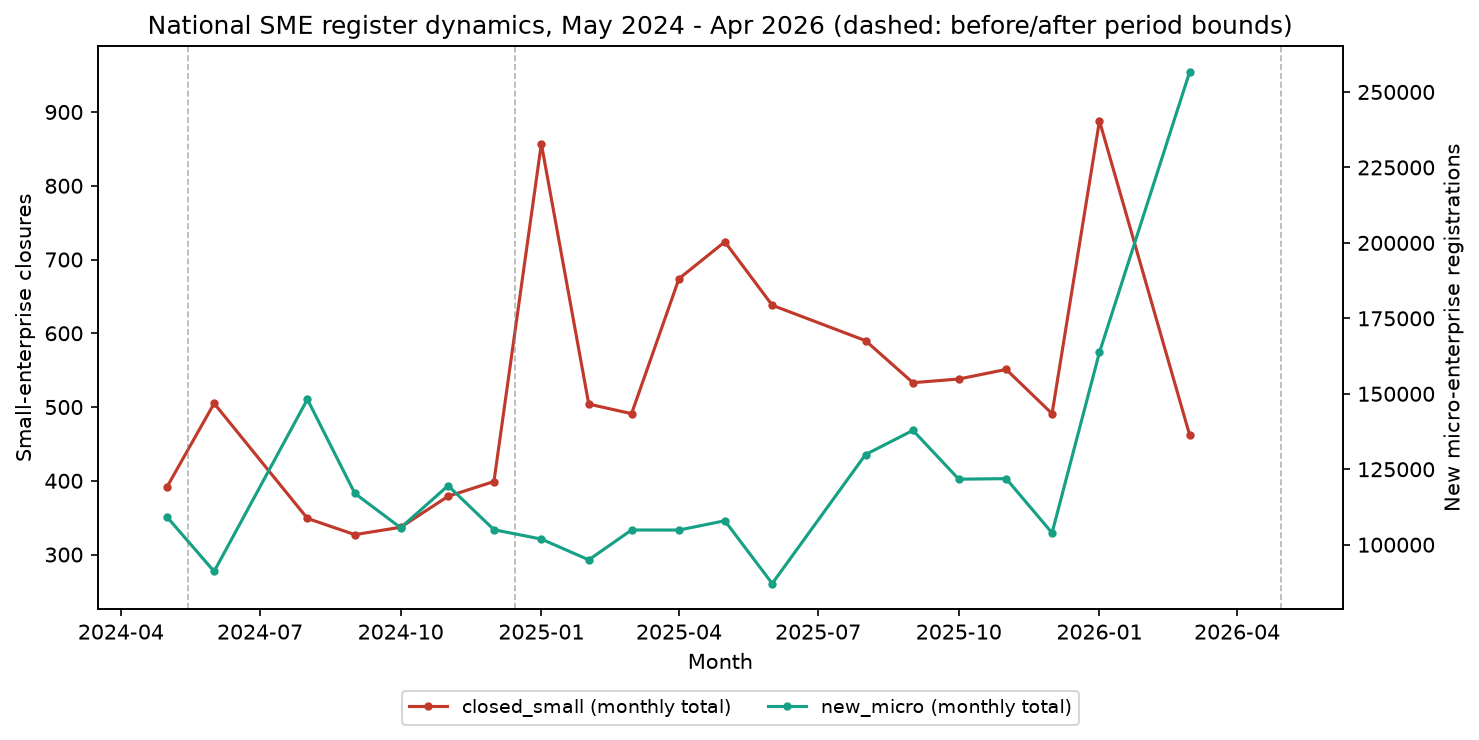

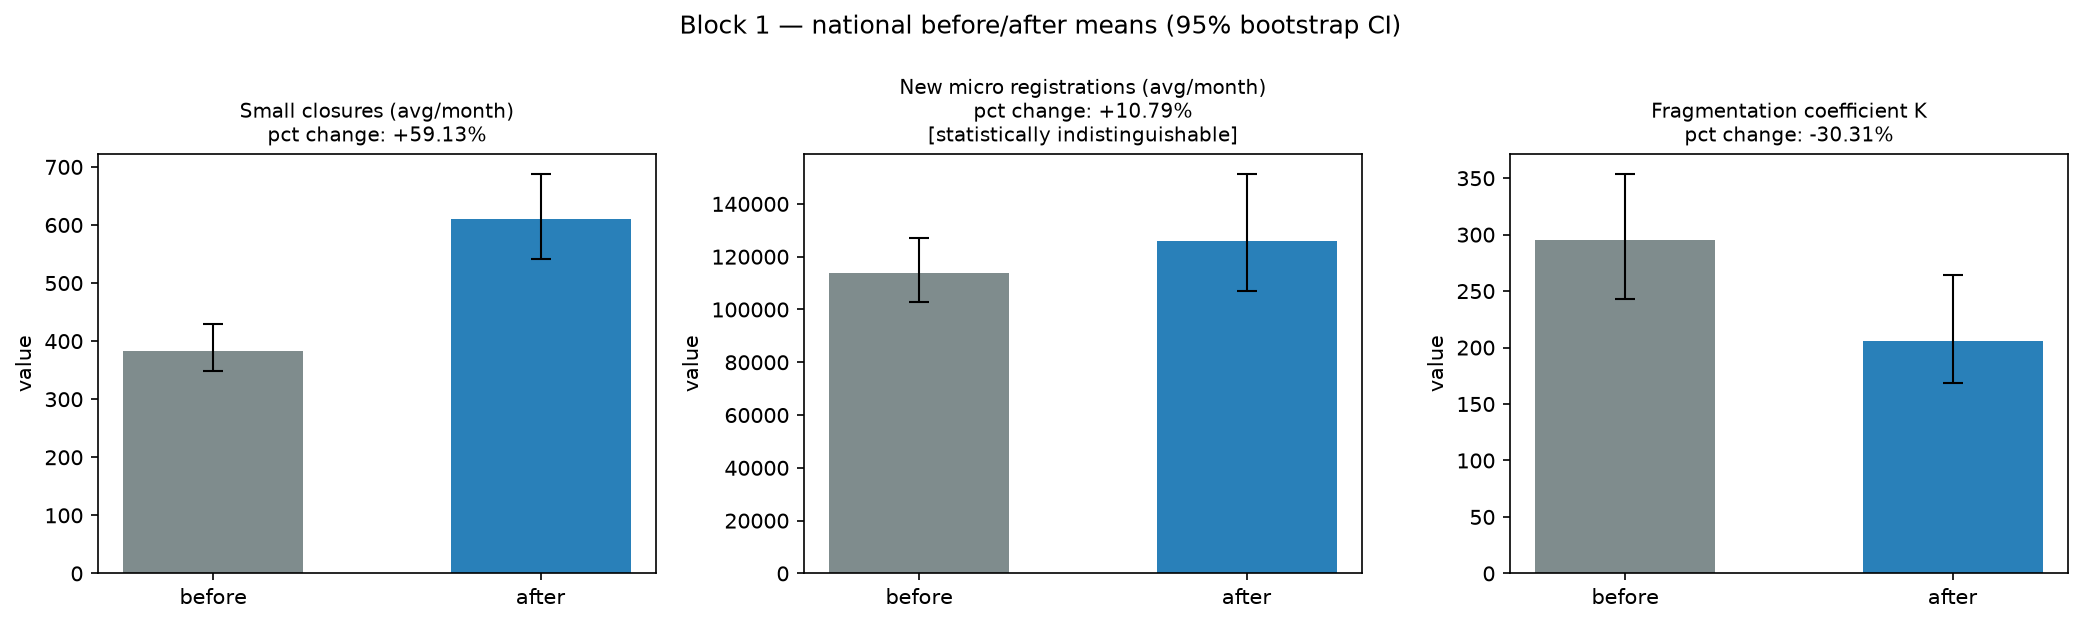

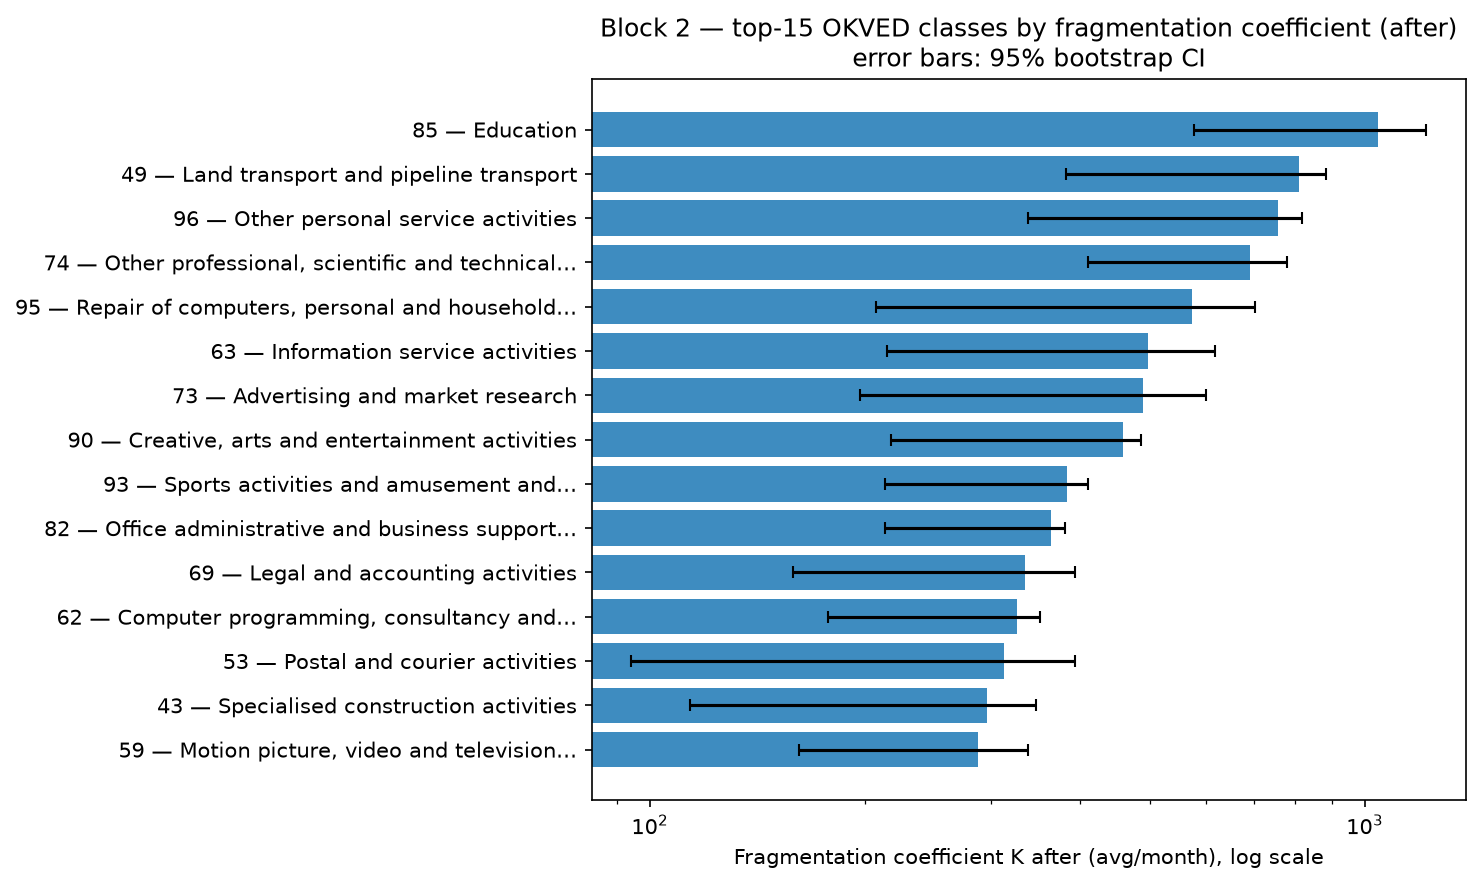

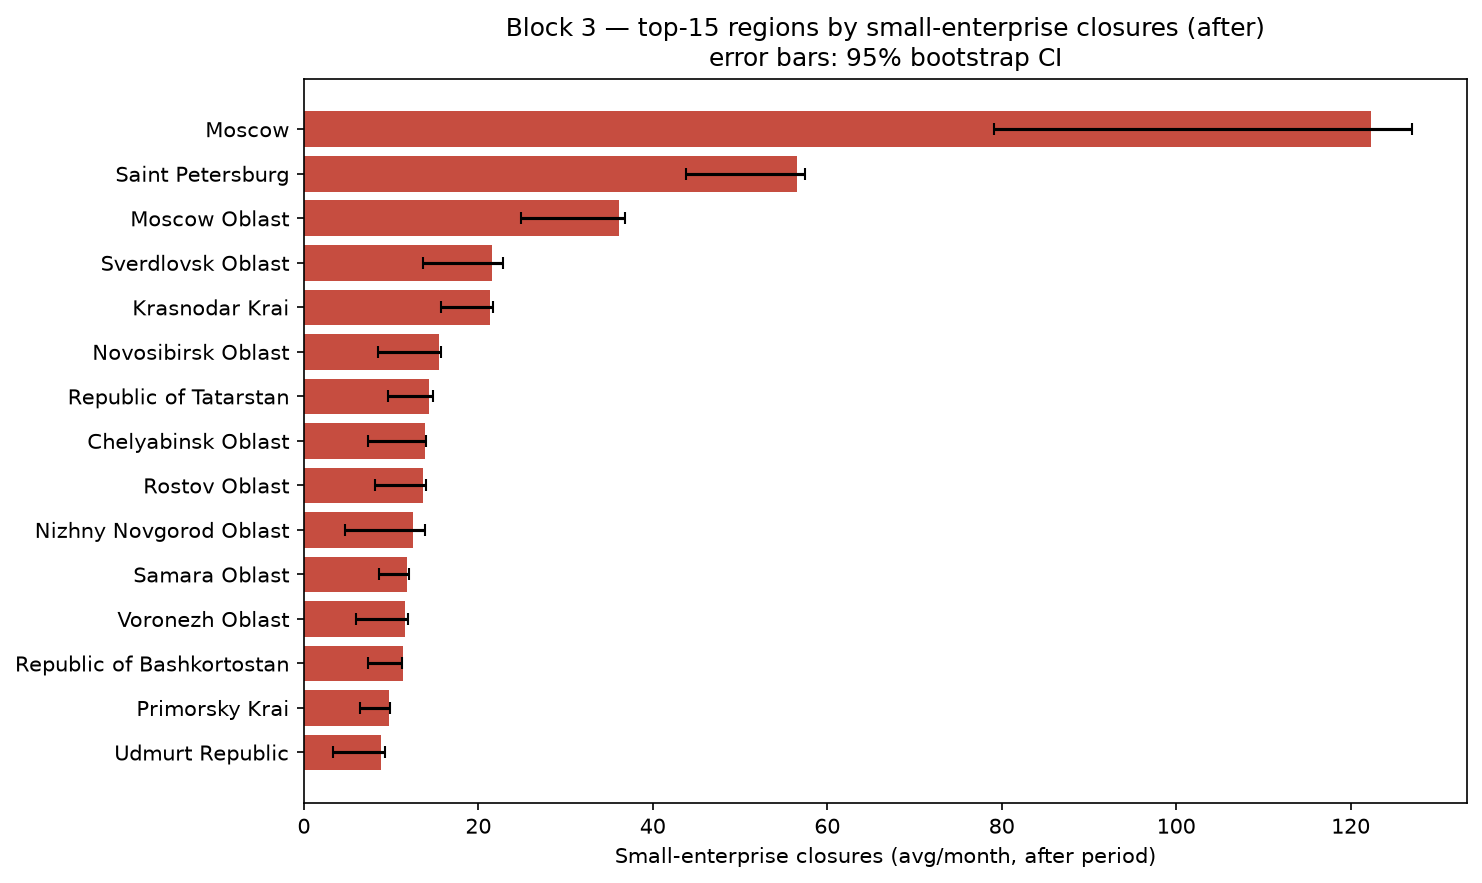

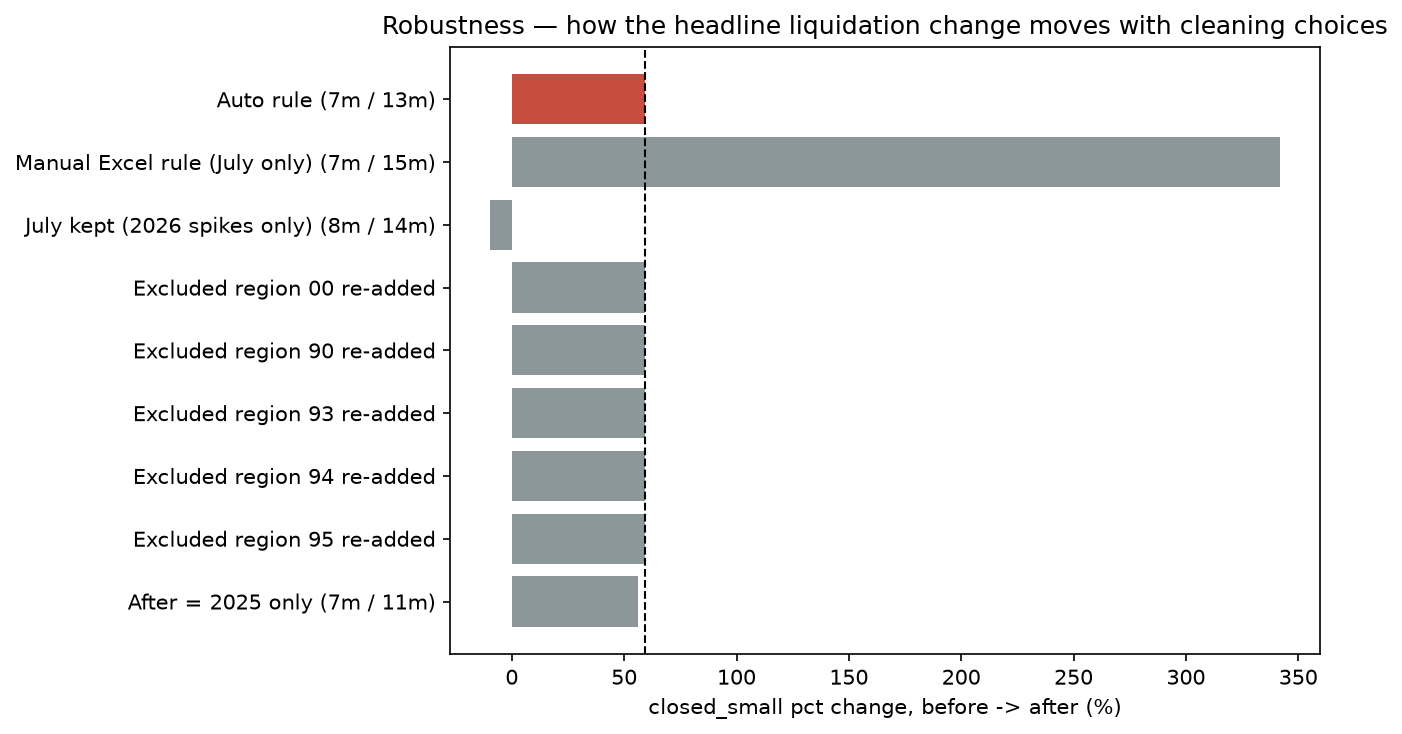

In [9]:
from IPython.display import Image, display
import os
figs = sorted(p.name for p in A.FIGURES_DIR.glob('*.png'))
print('figures in', A.FIGURES_DIR, ':', figs)
for f in ['fig1_national_trend', 'fig2_block1', 'fig3_block2_okved',
          'fig4_block3_regions', 'fig6_robustness']:
    if os.path.exists(f'../figures/{f}.png'):
        display(Image(filename=f'../figures/{f}.png'))